In [1]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import os
import matplotlib as mpl
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from sklearn import tree
from sklearn.cluster import DBSCAN
import pandas as pd
import umap
from Weighted_graph_measures import *

In [2]:
measures_names = [
                'Assortativity',
                'Average clustering coefficient',
                'Average shortest path length',
                'Average square clustering',
                'Degree (min)',
                'Degree (max)',
                'Degree (avg)',
                'Degree (std)',
                'Degree (med)',
                'Density',
                'Edge betweenness centrality (min)',
                'Edge betweenness centrality (max)',
                'Edge betweenness centrality (avg)',
                'Edge betweenness centrality (std)',
                'Edge betweenness centrality (med)',
                'Eccentricity (min)',
                'Eccentricity (max)',
                'Eccentricity (avg)',
                'Eccentricity (std)',
                'Eccentricity (med)',
                'Fraction of nodes in the barycenter',
                'Fraction of nodes in the center',
                'Fraction of nodes in the periphery',
                'Global efficiency',
                'Local efficiency (min)',
                'Local efficiency (max)',
                'Local efficiency (avg)',
                'Local efficiency (std)',
                'Local efficiency (med)',
                'Modularity',
                'Node betweenness centrality (min)',
                'Node betweenness centrality (max)',
                'Node betweenness centrality (avg)',
                'Node betweenness centrality (std)',
                'Node betweenness centrality (med)',
                'Node strength (min)',
                'Node strength (max)',
                'Node strength (avg)',
                'Node strength (std)',
                'Node strength (med)',
                'Rich club coefficient (min)',
                'Rich club coefficient (max)',
                'Rich club coefficient (avg)',
                'Rich club coefficient (std)',
                'Rich club coefficient (med)',
                'Transitivity']
nb_measures = len(measures_names)
nb_measures

46

48
signf_corr_before_Glut_Test2_Week_6_2022_08_25_14_23_52_FluoSZ9322_CS2A1S_stack_SZ_ts 0
F
350 57637
backbone
350 8586
backbone LCC
342 8586
graph init
signf_corr_before_Glut_Test2_Week_2_2022_08_03_16_10_31_FluoSZ9322_CS2A2S_stack_SZ_ts 1
F
528 98435
backbone
528 7544
backbone LCC
508 7544
graph init
signf_corr_before_Glut_Test2_Week_2_2022_09_02_10_37_23_FluoSZ17228_CS3A1S1_stack_SZ_ts 2
F
768 236151
backbone
768 20231
backbone LCC
764 20231
graph init
signf_corr_before_Glut_Test2_Week_2_2022_09_01_13_28_02_FluoSZ17228_CS2A1S1_stack_SZ_ts 3
F
833 343439
backbone
833 34534
backbone LCC
803 34534
graph init
signf_corr_before_Glut_Test2_Week_6_2022_09_30_10_53_21_FluoSZ17228_CS4A1S1_stack_SZ_ts 4
F
419 47980
backbone
419 2782
backbone LCC
389 2781
graph init
signf_corr_before_Glut_Test2_Week_2_2022_09_02_14_09_30_FluoSZ17228_CS4A1S1_stack_SZ_ts 5
F
524 65678
backbone
521 3505
backbone LCC
480 3503
graph init
signf_corr_before_Glut_Test2_Week_6_2022_08_25_11_53_52_FluoSZ9322_CS1A1S_sta

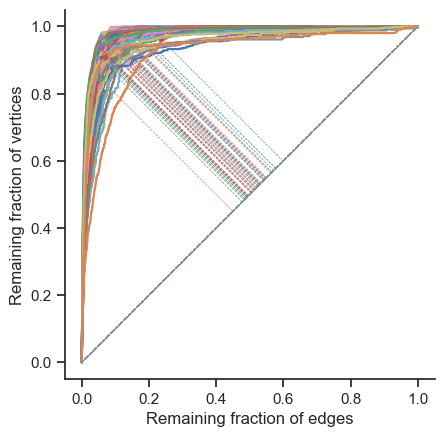

In [3]:
data_directory = "/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/graph_fingerprint/Raw_traces/corr_matrix_CTL_SZ_2_6/before_glut/"
graph_measures = np.empty((0,nb_measures))
all_npy_files = []
graph_names =[]
N = 0
for file in os.listdir(data_directory):
    if file.startswith("s"):
        if file.endswith(".npy"):
            all_npy_files.append(file)
print(len(all_npy_files))            
all_names = sorted(all_npy_files, key = lambda x: (str(x[-15:-8])))
N=0
#all_names
for file in all_names:
    name = os.path.splitext(file)[0]
    print(name,N)
    graph_names.append(name)
    adj = np.load(data_directory+ file)
    results = dict_to_vec(fingerprint_measures(np.abs(adj)))
    graph_measures = np.vstack((graph_measures,results))# np.real(results)))
    N=N+1

In [4]:
graph_measures.shape

(48, 46)

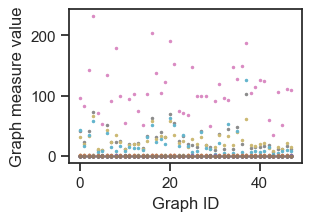

In [5]:
measures = np.nan_to_num(graph_measures)
# visualising graph measures values
plt.figure(figsize=(3,2))
plt.plot(measures,'.', markersize=3)
plt.ylabel('Graph measure value')
plt.xlabel('Graph ID')
#plt.savefig('unNormalized_graph_measure.svg')
plt.show()

In [6]:

save_path="/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/graph_fingerprint/Raw_traces/DF/"
# Create a DataFrame with the data and column names
df = pd.DataFrame(data=measures, columns=measures_names,index=graph_names)

# Save the DataFrame to a CSV file
df.to_csv(save_path+'abs(FC)_Raw_traces_before_Glut_CTL_SZ_Non_Normal_hIPSC_graph_measures.csv')

In [7]:
# normalizing values between 0-1
min_value = 0
max_value = 1
# Assuming measures.T is a 2D array with shape (?,?)
scaler = MinMaxScaler(feature_range=(min_value, max_value))

# Fit the scaler on your data and transform it
normalized_measures = scaler.fit_transform(measures)

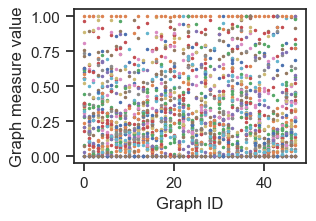

In [8]:
plt.figure(figsize=(3,2))
plt.plot(normalized_measures,'.', markersize=3)
plt.ylabel('Graph measure value')
plt.xlabel('Graph ID')
#plt.savefig('Normalized_graph_measure.svg')
plt.show()

In [9]:
# Create a DataFrame with the data and column names
df = pd.DataFrame(data=normalized_measures, columns=measures_names,index=graph_names)

# Save the DataFrame to a CSV file
df.to_csv(save_path+'abs(FC)_Raw_traces_before_Glut_CTL_SZ_Normal_hIPSC_graph_measures.csv')

In [10]:
normalized_measures.shape

(48, 46)

Text(0.5, 0, 'Measure ID')

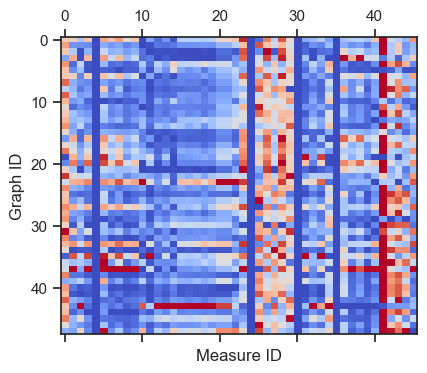

In [11]:
plt.matshow(normalized_measures, cmap='coolwarm',aspect=0.8)
plt.ylabel('Graph ID')
plt.xlabel('Measure ID')

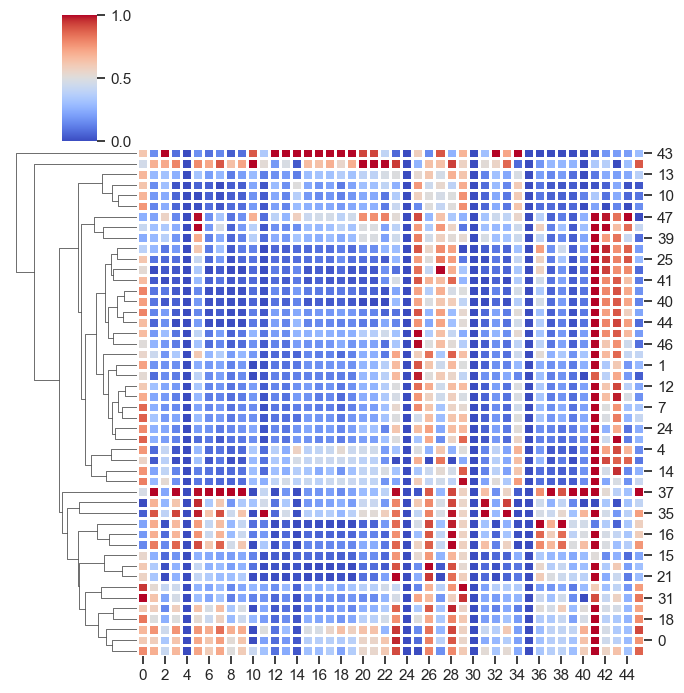

In [12]:
# Create a clustermap
g = sns.clustermap(normalized_measures,metric='euclidean', cmap='coolwarm',square=False,linewidths=0.9, figsize=(7, 7),
                   cbar_pos=(0.1, 0.8, 0.05, 0.18),colors_ratio=0.03, row_cluster=True, col_cluster=False)

In [13]:
corr = np.corrcoef(normalized_measures.T)

/Users/behnaz/miniconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/behnaz/miniconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


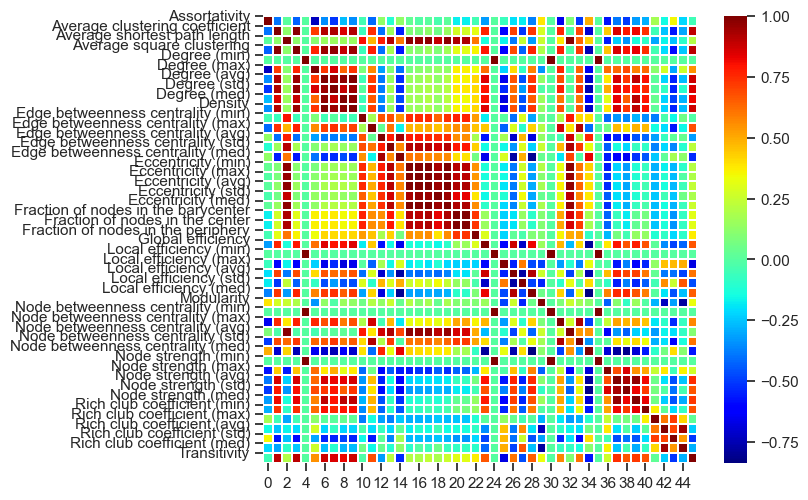

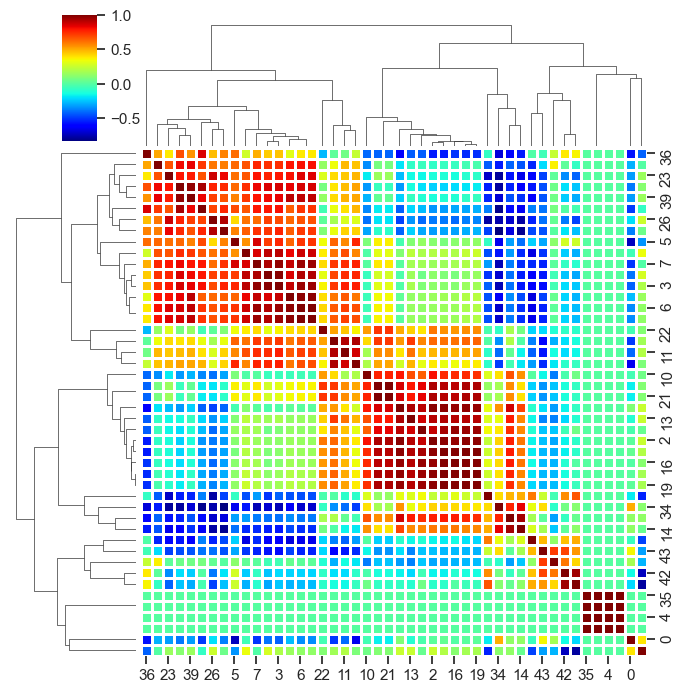

In [14]:
# Replace zero values with a small value
normalized_measures[normalized_measures == 0] = 1e-10

# Compute correlation matrix
corr = np.corrcoef(normalized_measures.T)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5.8))
g = sns.heatmap(corr, cmap='jet', linewidths=0.01)
plt.yticks(np.arange(len(measures_names)), measures_names, rotation=0)
plt.show()

# Create a clustermap
g = sns.clustermap(corr, metric='euclidean', cmap='jet', square=False, linewidths=0.9, figsize=(7, 7),
                   cbar_pos=(0.1, 0.8, 0.05, 0.18), colors_ratio=0.03, row_cluster=True, col_cluster=True)
plt.show()

In [15]:
ids = []
for i in range(len(all_names)):
    value = all_names[i].split('_')[-2]
    ids.append(str(value[0:2]))
print(ids)
print(len(ids))

['SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'SZ', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT', 'CT']
48


In [16]:
from sklearn.preprocessing import LabelEncoder
# Create a LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the labels to numerical values
numerical_labels = label_encoder.fit_transform(ids)

# Now, numerical_labels contains the numerical representation of the original labels
print(numerical_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0]


PCA variance ratio: [0.43443394 0.24205767 0.12678421 0.06699178]


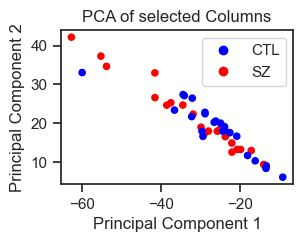

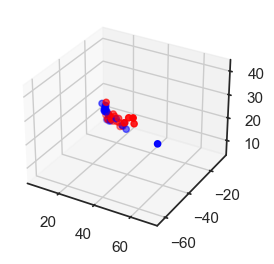

In [21]:
# # Apply PCA

pca = PCA(n_components=4)
pca.fit((normalized_measures))

print('PCA variance ratio:',pca.explained_variance_ratio_)

plt.figure(figsize=(3, 2))
X_pca = pca.transform(measures)
scatter = plt.scatter(X_pca[:,1], X_pca[:,2],s=20,c = np.array(numerical_labels),cmap='bwr')


# Add a legend
handles, labels = scatter.legend_elements()
legend_labels = ['CTL', 'SZ']
plt.legend(handles, legend_labels)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of selected Columns')

# Show the plot
plt.show()


fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=np.array(numerical_labels),s=20,cmap='bwr')
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


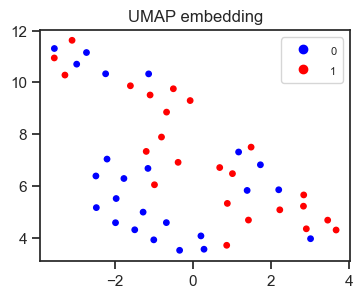

In [22]:
colors =["#1b3f7d","#5B85AA", "#91cbc2","white", "#f9e6ab", "#ea956a","#F46036"]
plt.figure(figsize=(4, 3))
fit = umap.UMAP(n_neighbors=10, min_dist=0.5, n_components=2)
u = fit.fit_transform(measures)
umap1 = u[:, 0] # first UMAP axis
umap2 = u[:, 1] # second UMAP axis
scatter =plt.scatter(u[:,0], u[:,1], c = np.array(numerical_labels), s=15.0,  cmap = 'bwr')
plt.title('UMAP embedding')

# Create a legend with unique numerical values
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]
unique_ids = np.unique(numerical_labels)
legend_labels = [f'{id}' for id in unique_ids]

# Extract handles from scatter.legend_elements()
handles, _ = scatter.legend_elements()
legend = plt.legend(handles=handles, labels=legend_labels, loc='upper right')

# Customize the legend title and labels
plt.setp(legend.get_title(), fontsize=10)
for text in legend.get_texts():
    text.set_fontsize(8)
#plt.savefig('UMAPEmbeding.svg')
plt.show()